# PaDiM — Détection d'anomalies par patchs multi-échelles

## Principe (PaDiM — CVPR 2021)
PaDiM est une méthode non supervisée qui modélise la distribution des features à chaque position spatiale.

1. **Features multi-échelles** : 3 couches d'EfficientNet (début, milieu, fin)
2. **Par position spatiale** : concaténation des features des 3 échelles
3. **Gaussienne multivariée** par position sur les features "good"
4. **Mahalanobis distance** pour une image test → heatmap d'anomalie
5. **Aucun entraînement** : juste extraction de features + calcul statistique


In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from scipy.spatial.distance import mahalanobis
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import load_img, img_to_array

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(f"✅ TensorFlow {tf.__version__}")

✅ TensorFlow 2.21.0


In [2]:
# ⚙️ Paramètres
BASE_DIR = "Dataset_128"
IMG_SIZE = 128

# 15 catégories MVTec AD
CATEGORIES = [
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper"
]

# Couches multi-échelles d'EfficientNetB0
FEATURE_LAYERS = ['block2a_activation',   # Début : (32, 32, 16)
                  'block4a_activation',   # Milieu : (16, 16, 112)
                  'block6a_activation']   # Fin :    (8, 8, 192)

print(f"📁 Dataset   : {BASE_DIR}/")
print(f"📏 Taille    : {IMG_SIZE}×{IMG_SIZE}")
print(f"🔬 Couches   : {FEATURE_LAYERS}")
print(f"📂 Catégories: {len(CATEGORIES)}")
for c in CATEGORIES:
    print(f"   - {c}")

📁 Dataset   : Dataset_128/
📏 Taille    : 128×128
🔬 Couches   : ['block2a_activation', 'block4a_activation', 'block6a_activation']
📂 Catégories: 15
   - bottle
   - cable
   - capsule
   - carpet
   - grid
   - hazelnut
   - leather
   - metal_nut
   - pill
   - screw
   - tile
   - toothbrush
   - transistor
   - wood
   - zipper


## 1. Chargement des données (unsupervised : que du good en train)

In [3]:
def load_train_good(base_dir, category, img_size=(IMG_SIZE, IMG_SIZE)):
    """Charge les images Train/good."""
    images = []
    train_dir = os.path.join(base_dir, "Train", category, "good")
    for fname in os.listdir(train_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = load_img(os.path.join(train_dir, fname), target_size=img_size, color_mode='rgb')
            images.append(img_to_array(img))
    return np.array(images)

def load_test_dataset(base_dir, category, img_size=(IMG_SIZE, IMG_SIZE)):
    """Charge les images Test (good + defective) avec labels."""
    images, labels = [], []
    test_dir = os.path.join(base_dir, "Test", category)
    for defect_type in sorted(os.listdir(test_dir)):
        folder = os.path.join(test_dir, defect_type)
        if not os.path.isdir(folder): continue
        label = 0 if defect_type == "good" else 1
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = load_img(os.path.join(folder, fname), target_size=img_size, color_mode='rgb')
                images.append(img_to_array(img))
                labels.append(label)
    return np.array(images), np.array(labels)

print("✅ Fonctions de chargement prêtes")

✅ Fonctions de chargement prêtes


## 2. Extraction de features multi-échelles

In [4]:
# Construire l'extracteur de features multi-échelles (une seule fois)
base_model = EfficientNetB0(include_top=False, weights='imagenet',
                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# Sorties des couches choisies
layer_outputs = [base_model.get_layer(name).output for name in FEATURE_LAYERS]
feature_extractor = keras.Model(inputs=base_model.input, outputs=layer_outputs,
                                 name="feature_extractor")

print(f"✅ Extracteur multi-échelles construit")
for i, name in enumerate(FEATURE_LAYERS):
    shape = feature_extractor.outputs[i].shape
    print(f"   {i}. {name:25s} → {shape}")

def extract_features(images, batch_size=32):
    """Extrait les features multi-échelles d'un batch d'images."""
    imgs_pp = tf.keras.applications.efficientnet.preprocess_input(images * 255.0)
    outputs = feature_extractor.predict(imgs_pp, batch_size=batch_size, verbose=0)
    return outputs  # Liste de tenseurs [batch, H, W, C]

✅ Extracteur multi-échelles construit
   0. block2a_activation        → (None, 32, 32, 96)
   1. block4a_activation        → (None, 8, 8, 240)
   2. block6a_activation        → (None, 4, 4, 672)


## 3. PaDiM : Modélisation gaussienne par position


                      🔍 PaDiM — bottle                      

📂 Chargement des données...
   Train (good): 391 | Test: 83 (good: 20, def: 63)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9992 | ⏱️ 3.8s
🎯 Seuil=15606154.00000 | ✅ Accuracy=0.9880 | Precision=1.0000 | Recall=0.9841 | F1=0.9920
   VP=62 FP=0 | FN=1 VN=20


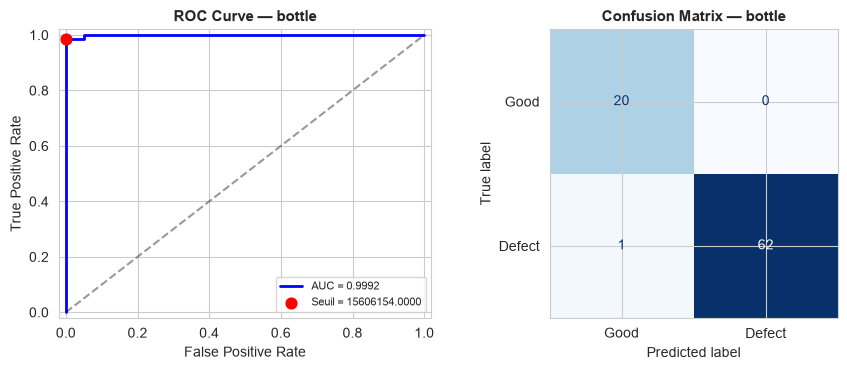


                      🔍 PaDiM — cable                       

📂 Chargement des données...
   Train (good): 391 | Test: 150 (good: 58, def: 92)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9224 | ⏱️ 2.1s
🎯 Seuil=81093512.00000 | ✅ Accuracy=0.8200 | Precision=0.9577 | Recall=0.7391 | F1=0.8344
   VP=68 FP=3 | FN=24 VN=55


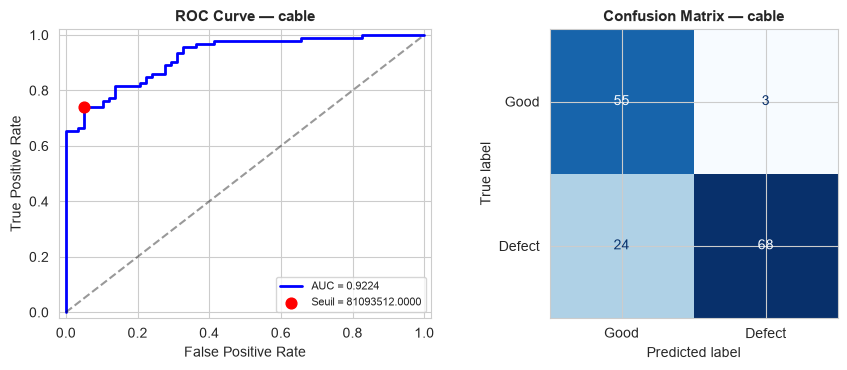


                     🔍 PaDiM — capsule                      

📂 Chargement des données...
   Train (good): 391 | Test: 132 (good: 23, def: 109)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.8524 | ⏱️ 1.9s
🎯 Seuil=4538365.00000 | ✅ Accuracy=0.8485 | Precision=0.9495 | Recall=0.8624 | F1=0.9038
   VP=94 FP=5 | FN=15 VN=18


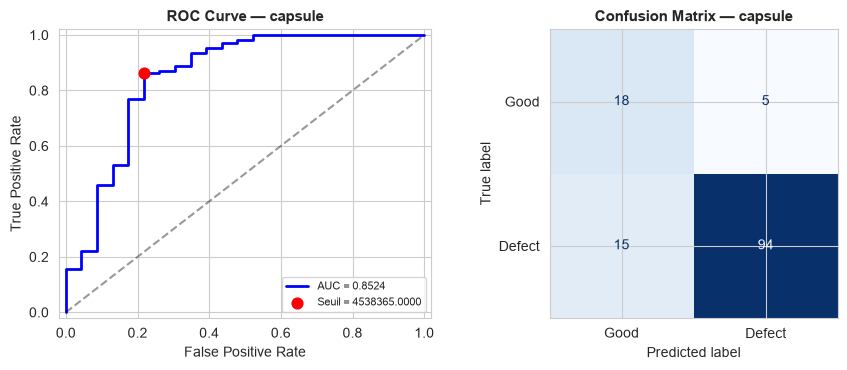


                      🔍 PaDiM — carpet                      

📂 Chargement des données...
   Train (good): 391 | Test: 117 (good: 28, def: 89)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9703 | ⏱️ 2.0s
🎯 Seuil=9503109.00000 | ✅ Accuracy=0.9744 | Precision=1.0000 | Recall=0.9663 | F1=0.9829
   VP=86 FP=0 | FN=3 VN=28


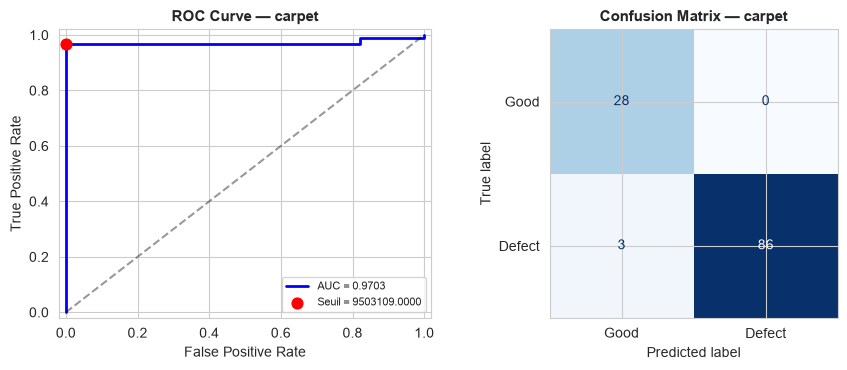


                       🔍 PaDiM — grid                       

📂 Chargement des données...
   Train (good): 391 | Test: 78 (good: 21, def: 57)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.8304 | ⏱️ 1.9s
🎯 Seuil=8856358.00000 | ✅ Accuracy=0.7051 | Precision=0.9250 | Recall=0.6491 | F1=0.7629
   VP=37 FP=3 | FN=20 VN=18


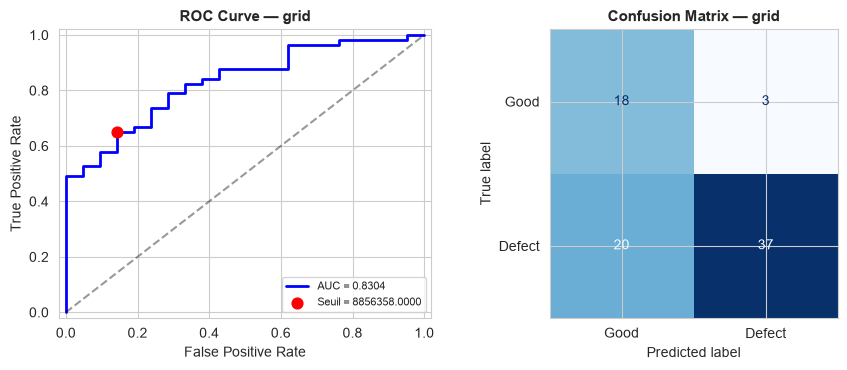


                     🔍 PaDiM — hazelnut                     

📂 Chargement des données...
   Train (good): 391 | Test: 110 (good: 40, def: 70)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9896 | ⏱️ 2.1s
🎯 Seuil=76594664.00000 | ✅ Accuracy=0.9545 | Precision=0.9710 | Recall=0.9571 | F1=0.9640
   VP=67 FP=2 | FN=3 VN=38


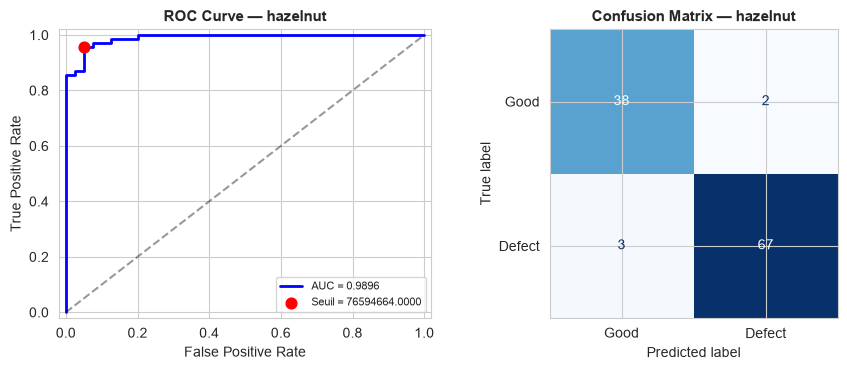


                     🔍 PaDiM — leather                      

📂 Chargement des données...
   Train (good): 391 | Test: 124 (good: 32, def: 92)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=1.0000 | ⏱️ 2.6s
🎯 Seuil=18751340.00000 | ✅ Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1=1.0000
   VP=92 FP=0 | FN=0 VN=32


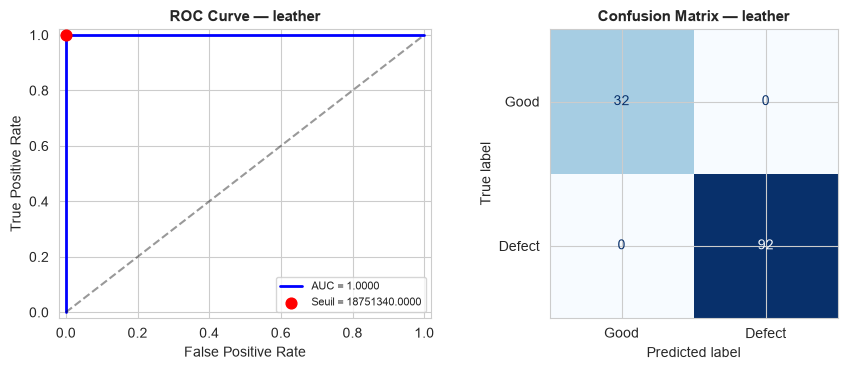


                    🔍 PaDiM — metal_nut                     

📂 Chargement des données...
   Train (good): 391 | Test: 115 (good: 22, def: 93)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9907 | ⏱️ 2.2s
🎯 Seuil=32339112.00000 | ✅ Accuracy=0.9565 | Precision=0.9889 | Recall=0.9570 | F1=0.9727
   VP=89 FP=1 | FN=4 VN=21


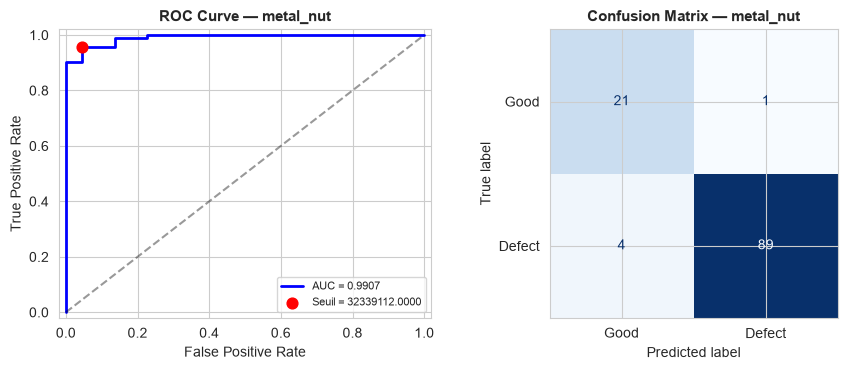


                       🔍 PaDiM — pill                       

📂 Chargement des données...
   Train (good): 391 | Test: 167 (good: 26, def: 141)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.8464 | ⏱️ 2.0s
🎯 Seuil=27347632.00000 | ✅ Accuracy=0.7305 | Precision=0.9615 | Recall=0.7092 | F1=0.8163
   VP=100 FP=4 | FN=41 VN=22


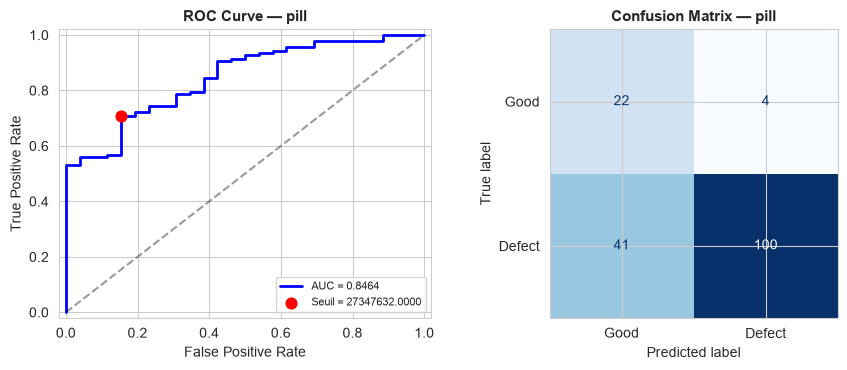


                      🔍 PaDiM — screw                       

📂 Chargement des données...
   Train (good): 391 | Test: 160 (good: 41, def: 119)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.7975 | ⏱️ 2.0s
🎯 Seuil=33680468.00000 | ✅ Accuracy=0.7250 | Precision=0.9032 | Recall=0.7059 | F1=0.7925
   VP=84 FP=9 | FN=35 VN=32


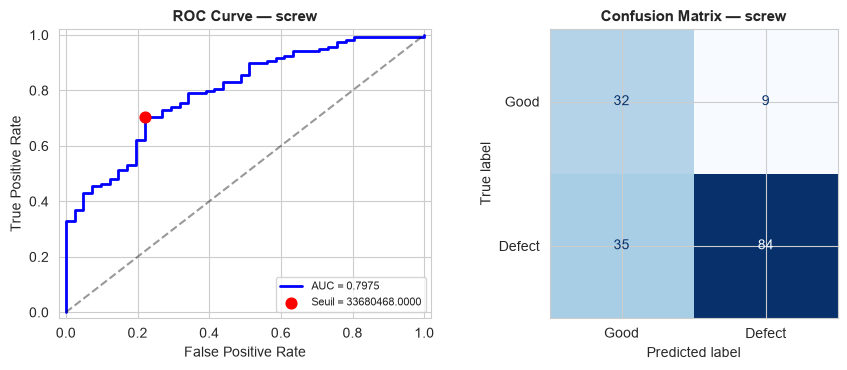


                       🔍 PaDiM — tile                       

📂 Chargement des données...
   Train (good): 391 | Test: 117 (good: 33, def: 84)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9953 | ⏱️ 1.9s
🎯 Seuil=28395920.00000 | ✅ Accuracy=0.9829 | Precision=0.9881 | Recall=0.9881 | F1=0.9881
   VP=83 FP=1 | FN=1 VN=32


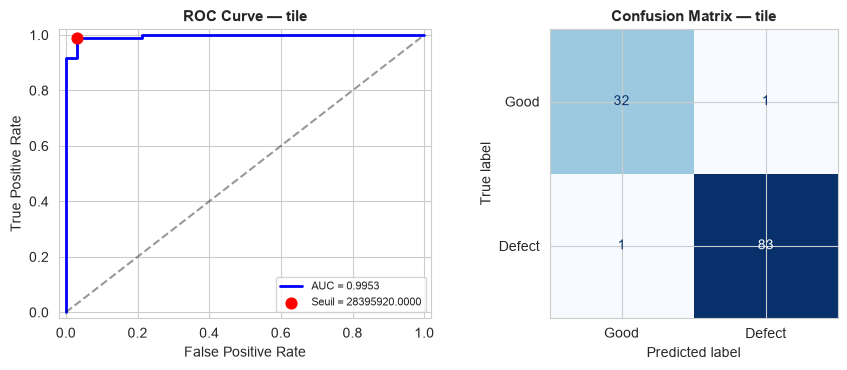


                    🔍 PaDiM — toothbrush                    

📂 Chargement des données...
   Train (good): 391 | Test: 42 (good: 12, def: 30)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.8694 | ⏱️ 2.1s
🎯 Seuil=16404104.00000 | ✅ Accuracy=0.8810 | Precision=0.9032 | Recall=0.9333 | F1=0.9180
   VP=28 FP=3 | FN=2 VN=9


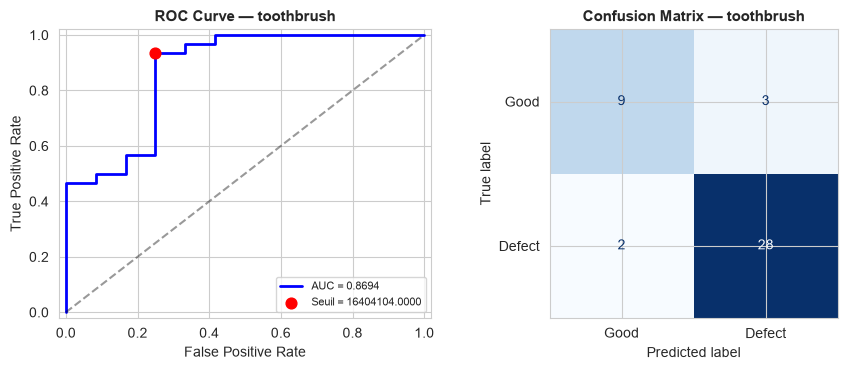


                    🔍 PaDiM — transistor                    

📂 Chargement des données...
   Train (good): 391 | Test: 100 (good: 60, def: 40)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9908 | ⏱️ 1.9s
🎯 Seuil=24034716.00000 | ✅ Accuracy=0.9500 | Precision=0.8889 | Recall=1.0000 | F1=0.9412
   VP=40 FP=5 | FN=0 VN=55


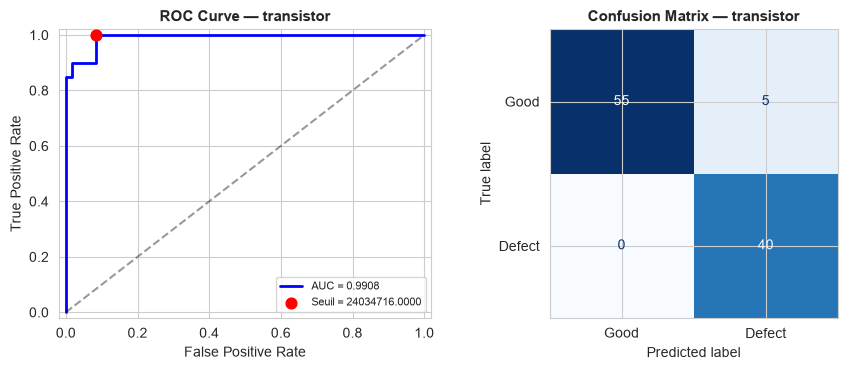


                       🔍 PaDiM — wood                       

📂 Chargement des données...
   Train (good): 391 | Test: 79 (good: 19, def: 60)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9754 | ⏱️ 1.8s
🎯 Seuil=72882464.00000 | ✅ Accuracy=0.9114 | Precision=0.9818 | Recall=0.9000 | F1=0.9391
   VP=54 FP=1 | FN=6 VN=18


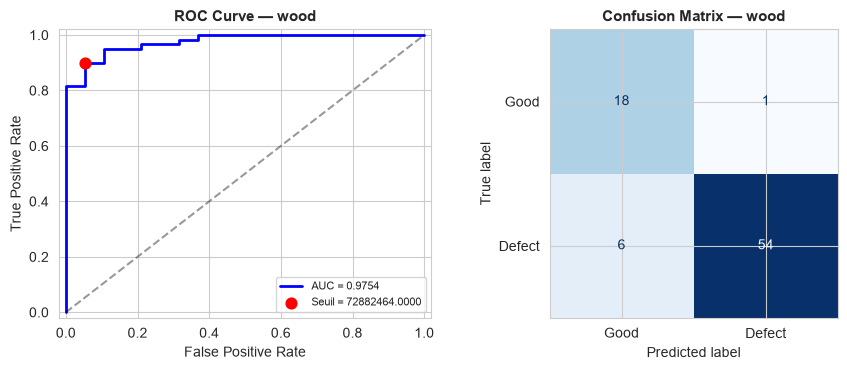


                      🔍 PaDiM — zipper                      

📂 Chargement des données...
   Train (good): 391 | Test: 151 (good: 32, def: 119)
📤 Extraction features train...
   Grille: 8×8 | Features: 1008

📊 AUC=0.9580 | ⏱️ 1.9s
🎯 Seuil=4882573.00000 | ✅ Accuracy=0.9536 | Precision=0.9590 | Recall=0.9832 | F1=0.9710
   VP=117 FP=5 | FN=2 VN=27


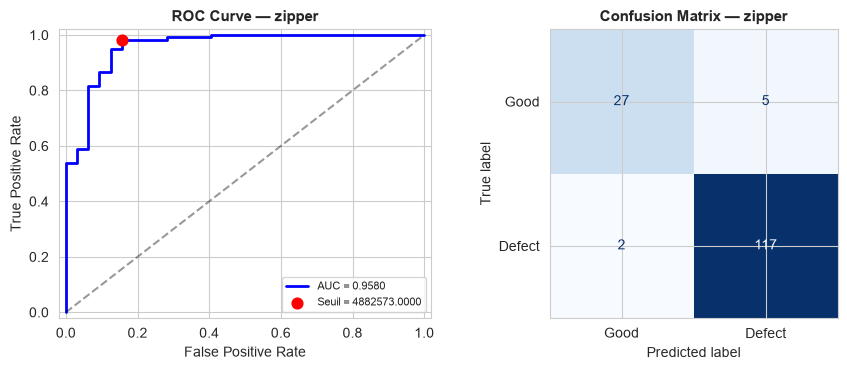



                  📊 BENCHMARK PaDiM — 15 catégories                   
Catégorie            AUC    Temps
-------------------------------
bottle            0.9992     3.8s
cable             0.9224     2.1s
capsule           0.8524     1.9s
carpet            0.9703     2.0s
grid              0.8304     1.9s
hazelnut          0.9896     2.1s
leather           1.0000     2.6s
metal_nut         0.9907     2.2s
pill              0.8464     2.0s
screw             0.7975     2.0s
tile              0.9953     1.9s
toothbrush        0.8694     2.1s
transistor        0.9908     1.9s
wood              0.9754     1.8s
zipper            0.9580     1.9s
-------------------------------
MOYENNE           0.9325

🖼️ Heatmaps pour zipper (dernière catégorie)


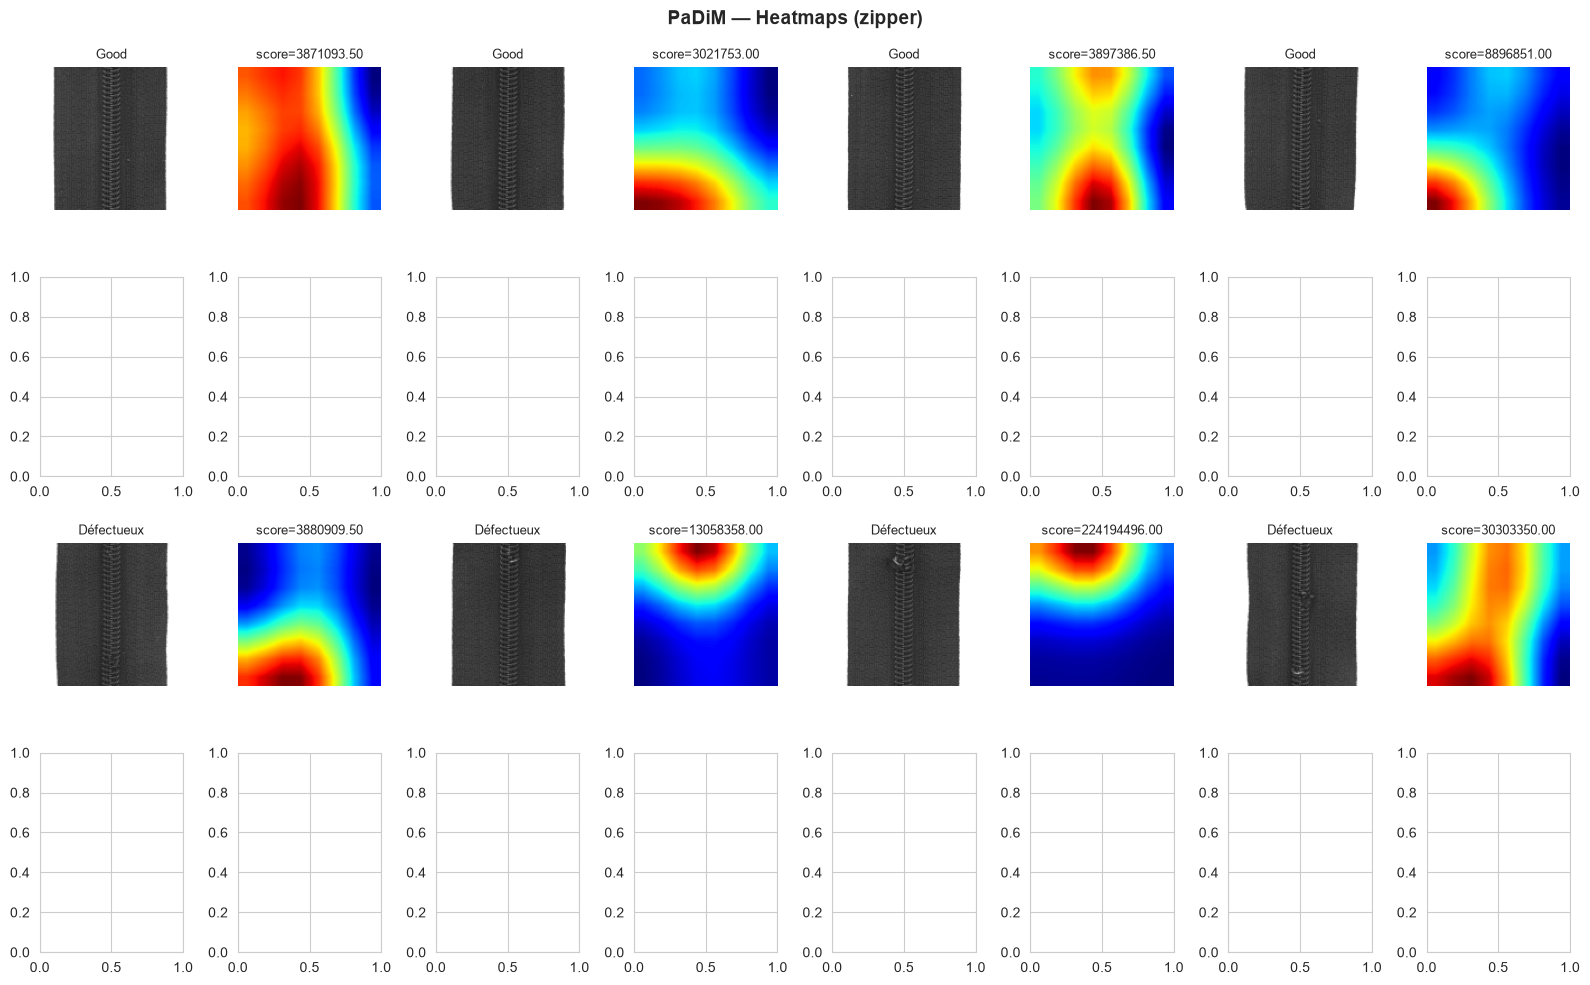

In [5]:
# 📊 Boucle sur toutes les catégories
results = {}       # {catégorie: {"auc": ..., "time": ..., ...}}
all_preds = {}     # {catégorie: {"y_true": ..., "scores": ...}}
all_anomaly_maps = {}  # Pour la visualisation finale

for category in CATEGORIES:
    print(f"\n{'='*60}")
    print(f"{'🔍 PaDiM — ' + category:^60}")
    print(f"{'='*60}")
    t_cat = time.time()
    
    # ---- 1. Chargement ----
    print("\n📂 Chargement des données...")
    train_dir = os.path.join(BASE_DIR, "Train", category, "good")
    X_train = load_train_good(BASE_DIR, category)
    X_train = X_train / 255.0
    X_test, y_test = load_test_dataset(BASE_DIR, category)
    X_test = X_test / 255.0
    print(f"   Train (good): {X_train.shape[0]} | Test: {X_test.shape[0]} (good: {(y_test==0).sum()}, def: {(y_test==1).sum()})")
    
    # ---- 2. Extraction features train ----
    print("📤 Extraction features train...")
    train_feats = extract_features(X_train)
    target_h, target_w = train_feats[1].shape[1:3]
    n_feats = sum(f.shape[-1] for f in train_feats)
    
    train_feats_resized = [tf.image.resize(f, (target_h, target_w)).numpy() for f in train_feats]
    stacked_feats = np.concatenate(train_feats_resized, axis=-1)
    
    # ---- 3. Modélisation gaussienne ----
    padim_mean = np.zeros((target_h, target_w, n_feats), dtype=np.float32)
    padim_cov = np.zeros((target_h, target_w, n_feats, n_feats), dtype=np.float32)
    
    for h in range(target_h):
        for w in range(target_w):
            position_feats = stacked_feats[:, h, w, :]
            padim_mean[h, w] = np.mean(position_feats, axis=0)
            cov = np.cov(position_feats, rowvar=False)
            cov += np.eye(n_feats) * 1e-6
            padim_cov[h, w] = cov
    padim_cov_inv = np.linalg.inv(padim_cov)
    print(f"   Grille: {target_h}×{target_w} | Features: {n_feats}")
    
    # ---- 4. Évaluation ----
    test_feats = extract_features(X_test)
    test_feats_resized = [tf.image.resize(f, (target_h, target_w)).numpy() for f in test_feats]
    stacked_test_feats = np.concatenate(test_feats_resized, axis=-1)
    
    N_test = X_test.shape[0]
    anomaly_maps = np.zeros((N_test, target_h, target_w), dtype=np.float32)
    
    for h in range(target_h):
        for w in range(target_w):
            diff = stacked_test_feats[:, h, w, :] - padim_mean[h, w]
            left = np.dot(diff, padim_cov_inv[h, w])
            anomaly_maps[:, h, w] = np.sum(left * diff, axis=-1)
    
    global_scores = np.max(anomaly_maps, axis=(1, 2))
    auc = roc_auc_score(y_test, global_scores)
    
    elapsed = time.time() - t_cat
    
    # 5. Métriques détaillées
    fpr, tpr, thresholds = roc_curve(y_test, global_scores)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    best_thresh = thresholds[best_idx]
    y_pred = (global_scores >= best_thresh).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    results[category] = {
        "auc": auc, "time": elapsed, "accuracy": accuracy,
        "precision": precision, "recall": recall, "f1": f1,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "threshold": best_thresh
    }
    all_preds[category] = {"y_true": y_test.copy(), "scores": global_scores.copy()}
    all_anomaly_maps[category] = (X_test, y_test, anomaly_maps, global_scores)
    
    print(f"\n📊 AUC={auc:.4f} | ⏱️ {elapsed:.1f}s")
    print(f"🎯 Seuil={best_thresh:.5f} | ✅ Accuracy={accuracy:.4f} | Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f}")
    print(f"   VP={tp} FP={fp} | FN={fn} VN={tn}")
    
    # ROC + Confusion Matrix
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))
    ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax1.scatter(fpr[best_idx], tpr[best_idx], color='red', s=60, zorder=5,
                label=f'Seuil = {best_thresh:.4f}')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve — {category}', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=8, loc='lower right')
    ax1.set_xlim(-0.02, 1.02); ax1.set_ylim(-0.02, 1.02)
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Good', 'Defect'],
        cmap='Blues', ax=ax2, colorbar=False, values_format='d'
    )
    ax2.set_title(f'Confusion Matrix — {category}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ---- 5. Résumé final ----
print(f"\n\n{'='*70}")
print(f"{'📊 BENCHMARK PaDiM — 15 catégories':^70}")
print(f"{'='*70}")
print(f"{'Catégorie':<15} {'AUC':>8} {'Temps':>8}")
print(f"{'-'*31}")
for cat in CATEGORIES:
    r = results[cat]
    print(f"{cat:<15} {r['auc']:>8.4f} {r['time']:>7.1f}s")
print(f"{'-'*31}")
mean_auc = np.mean([r['auc'] for r in results.values()])
print(f"{'MOYENNE':<15} {mean_auc:>8.4f}")
print(f"{'='*70}")

# Visualisation des heatmaps pour la dernière catégorie
print(f"\n🖼️ Heatmaps pour {category} (dernière catégorie)")
good_idx = np.where(all_anomaly_maps[category][1] == 0)[0][:4]
defect_idx = np.where(all_anomaly_maps[category][1] == 1)[0][:4]
X_test_last, _, amaps_last, scores_last = all_anomaly_maps[category]

fig, axes = plt.subplots(4, 8, figsize=(16, 10))
fig.suptitle(f"PaDiM — Heatmaps ({category})", fontsize=14, fontweight='bold')

for row, indices, title in [(0, good_idx, 'Good'), (2, defect_idx, 'Défectueux')]:
    for col, idx in enumerate(indices[:4]):
        img = X_test_last[idx]
        amap = amaps_last[idx]
        amap_smooth = gaussian_filter(amap, sigma=2)
        amap_resized = tf.image.resize(amap_smooth[..., np.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
        
        axes[row, col * 2].imshow(img)
        axes[row, col * 2].set_title(f"{title}", fontsize=9)
        axes[row, col * 2].axis('off')
        
        im = axes[row, col * 2 + 1].imshow(amap_resized, cmap='jet')
        axes[row, col * 2 + 1].set_title(f"score={scores_last[idx]:.2f}", fontsize=9)
        axes[row, col * 2 + 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Synthèse visuelle — Toutes les catégories


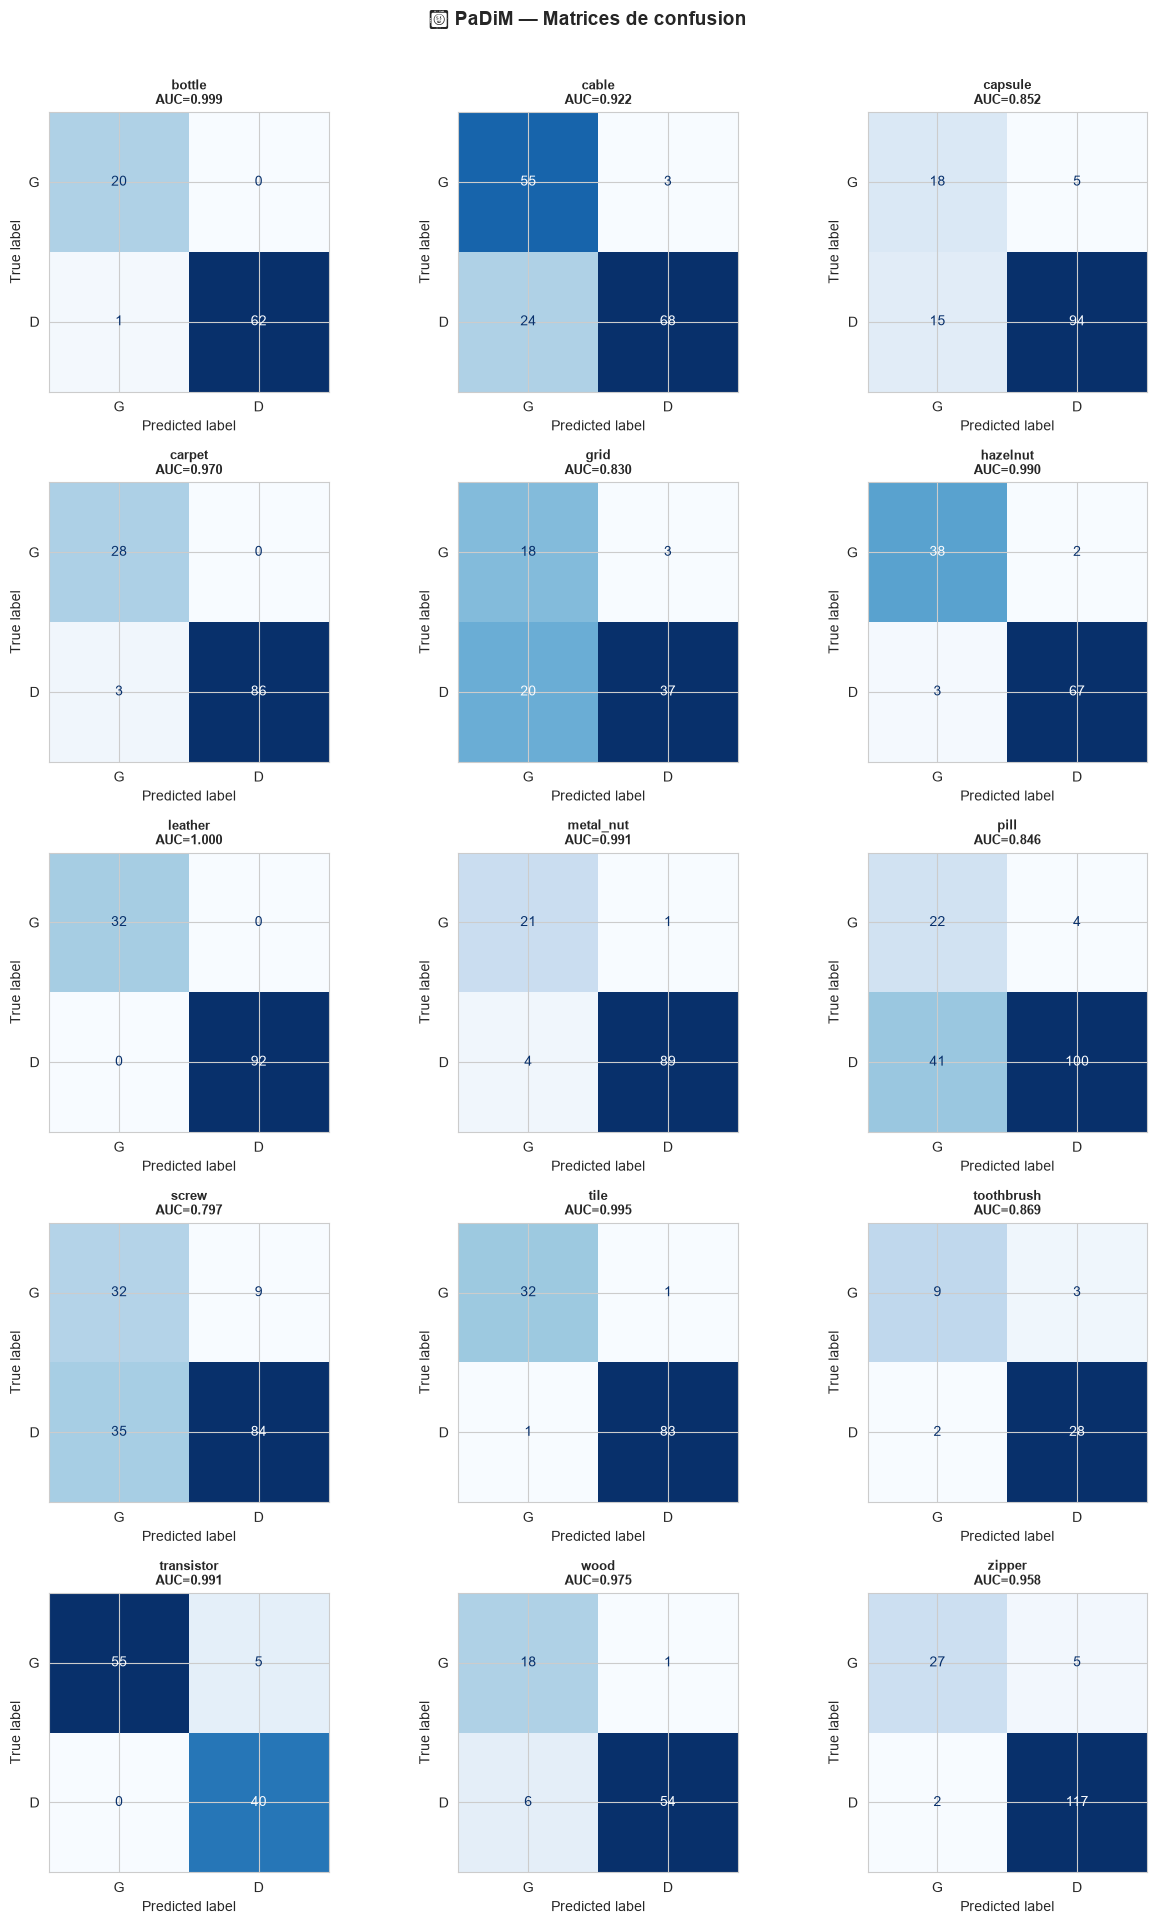


                                    📊 SYNTHÈSE COMPLÈTE — PaDiM                                     
Catégorie          AUC     Seuil  Accuracy  Precision   Recall      F1   VP   FP   FN   VN
----------------------------------------------------------------------------------------------------
bottle           0.999 15606154.00000     0.988      1.000    0.984   0.992   62    0    1   20
cable            0.922 81093512.00000     0.820      0.958    0.739   0.834   68    3   24   55
capsule          0.852 4538365.00000     0.848      0.949    0.862   0.904   94    5   15   18
carpet           0.970 9503109.00000     0.974      1.000    0.966   0.983   86    0    3   28
grid             0.830 8856358.00000     0.705      0.925    0.649   0.763   37    3   20   18
hazelnut         0.990 76594664.00000     0.955      0.971    0.957   0.964   67    2    3   38
leather          1.000 18751340.00000     1.000      1.000    1.000   1.000   92    0    0   32
metal_nut        0.991 32339112.00000

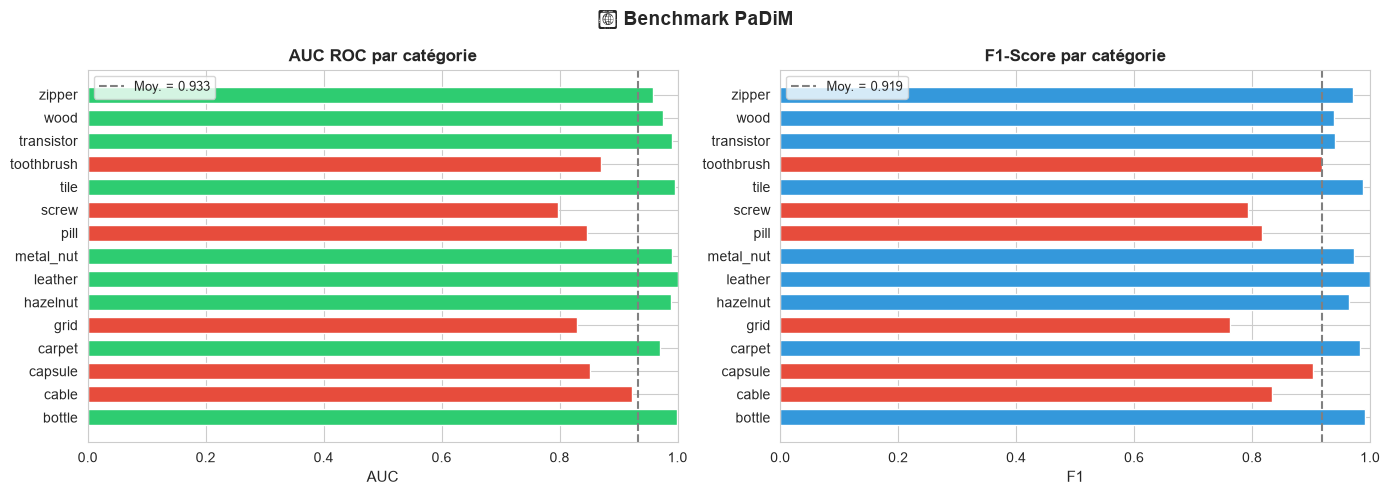

In [6]:
# ─── Synthèse : grille des matrices + histogrammes ───

if 'all_preds' not in dir() or len(all_preds) == 0:
    print("⚠️  `all_preds` est vide. Exécute d'abord la cellule d'entraînement.")
else:
    # ── 1. Grille des matrices de confusion ──
    n_cats = len(CATEGORIES)
    n_cols = 3
    n_rows = int(np.ceil(n_cats / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.8))
    axes = axes.flatten()
    
    for idx, cat in enumerate(CATEGORIES):
        ax = axes[idx]
        y_true = all_preds[cat]["y_true"]
        scores = all_preds[cat]["scores"]
        
        fpr, tpr, thresholds = roc_curve(y_true, scores)
        best_t = thresholds[np.argmax(tpr - fpr)]
        y_pred = (scores >= best_t).astype(int)
        
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, display_labels=['G', 'D'],
            cmap='Blues', ax=ax, colorbar=False, values_format='d'
        )
        ax.set_title(f'{cat}\nAUC={roc_auc_score(y_true, scores):.3f}',
                     fontsize=9, fontweight='bold')
    
    for idx in range(n_cats, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('🧩 PaDiM — Matrices de confusion',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    
    # ── 2. Tableau récapitulatif ──
    metrics_list = ['auc', 'accuracy', 'precision', 'recall', 'f1']
    print(f"\n{'='*100}")
    print(f"{'📊 SYNTHÈSE COMPLÈTE — PaDiM':^100}")
    print(f"{'='*100}")
    print(f"{'Catégorie':<14} {'AUC':>7} {'Seuil':>9} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>7} {'VP':>4} {'FP':>4} {'FN':>4} {'VN':>4}")
    print(f"{'-'*100}")
    
    all_vals = {k: [] for k in metrics_list}
    for cat in CATEGORIES:
        r = results[cat]
        print(f"{cat:<14} {r['auc']:>7.3f} {r['threshold']:>9.5f} {r['accuracy']:>9.3f} {r['precision']:>10.3f} {r['recall']:>8.3f} {r['f1']:>7.3f} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {r['tn']:>4}")
        for k in metrics_list:
            all_vals[k].append(r[k])
    
    print(f"{'-'*100}")
    print(f"{'MOYENNE':<14}", end='')
    for k in metrics_list:
        print(f" {np.mean(all_vals[k]):>7.3f}", end=' ' if k != 'f1' else '')
    print(f"{'':->28}")
    print(f"{'ÉCART-TYPE':<14}", end='')
    for k in metrics_list:
        print(f" {np.std(all_vals[k]):>7.3f}", end=' ' if k != 'f1' else '')
    print(f"\n{'='*100}")
    
    # ── 3. Barres horizontales ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title, color in [
        (axes[0], 'auc', 'AUC ROC', '#2ecc71'),
        (axes[1], 'f1', 'F1-Score', '#3498db')
    ]:
        vals = [results[cat][metric] for cat in CATEGORIES]
        colors = [color if v >= np.mean(vals) else '#e74c3c' for v in vals]
        ax.barh(CATEGORIES, vals, color=colors, edgecolor='white', height=0.7)
        ax.axvline(np.mean(vals), color='gray', linestyle='--',
                    label=f'Moy. = {np.mean(vals):.3f}')
        ax.set_xlabel(metric.upper(), fontsize=11)
        ax.set_title(f'{title} par catégorie', fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.legend(fontsize=9)
    
    plt.suptitle('📊 Benchmark PaDiM', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()